Ball-by-ball: 277,710 rows × 10 columns
Match info: 1,098 rows × 9 columns
DISTRIBUTION ANALYSIS


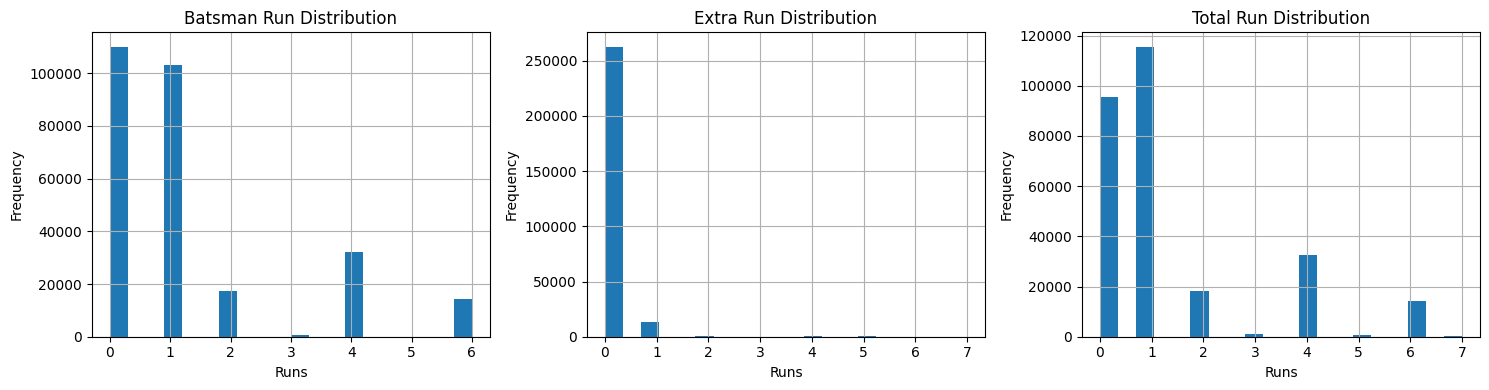

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ball_by_ball = pd.read_csv('/kaggle/input/cleaned-cricket-dataset/ball_by_ball_cleaned.csv')
match_info = pd.read_csv('/kaggle/input/cleaned-cricket-dataset/match_info_cleaned.csv')

print(f"Ball-by-ball: {ball_by_ball.shape[0]:,} rows × {ball_by_ball.shape[1]} columns")
print(f"Match info: {match_info.shape[0]:,} rows × {match_info.shape[1]} columns")

print("="*50)
print("DISTRIBUTION ANALYSIS")
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ball_by_ball['batsman_run'].hist(bins=20, ax=axes[0])
axes[0].set_title('Batsman Run Distribution')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Frequency')

ball_by_ball['extra_run'].hist(bins=20, ax=axes[1])
axes[1].set_title('Extra Run Distribution')
axes[1].set_xlabel('Runs')
axes[1].set_ylabel('Frequency')

ball_by_ball['total_run'].hist(bins=20, ax=axes[2])
axes[2].set_title('Total Run Distribution')
axes[2].set_xlabel('Runs')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()





Run Distribution Summary:
         batsman_run      extra_run      total_run
count  277710.000000  277710.000000  277710.000000
mean        1.277487       0.067970       1.345457
std         1.651212       0.343004       1.637716
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%         1.000000       0.000000       1.000000
75%         1.000000       0.000000       1.000000
max         6.000000       7.000000       7.000000
OUTLIER VISUALIZATION


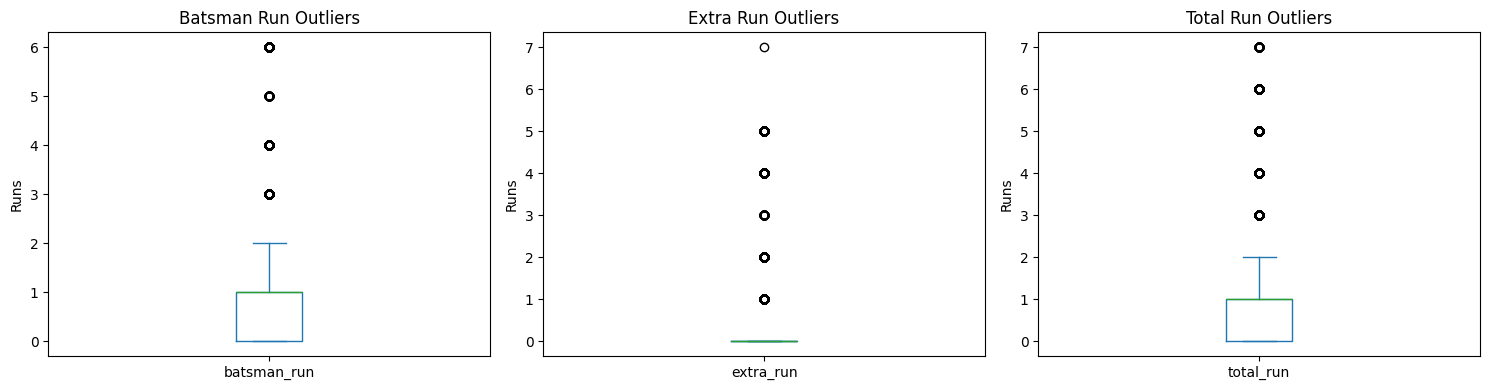

In [3]:
print("\nRun Distribution Summary:")
print(ball_by_ball[['batsman_run', 'extra_run', 'total_run']].describe())

print("="*50)
print("OUTLIER VISUALIZATION")
print("="*50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ball_by_ball[['batsman_run']].plot(kind='box', ax=axes[0])
axes[0].set_title('Batsman Run Outliers')
axes[0].set_ylabel('Runs')

ball_by_ball[['extra_run']].plot(kind='box', ax=axes[1])
axes[1].set_title('Extra Run Outliers')
axes[1].set_ylabel('Runs')

ball_by_ball[['total_run']].plot(kind='box', ax=axes[2])
axes[2].set_title('Total Run Outliers')
axes[2].set_ylabel('Runs')

plt.tight_layout()
plt.show()





CORRELATION ANALYSIS


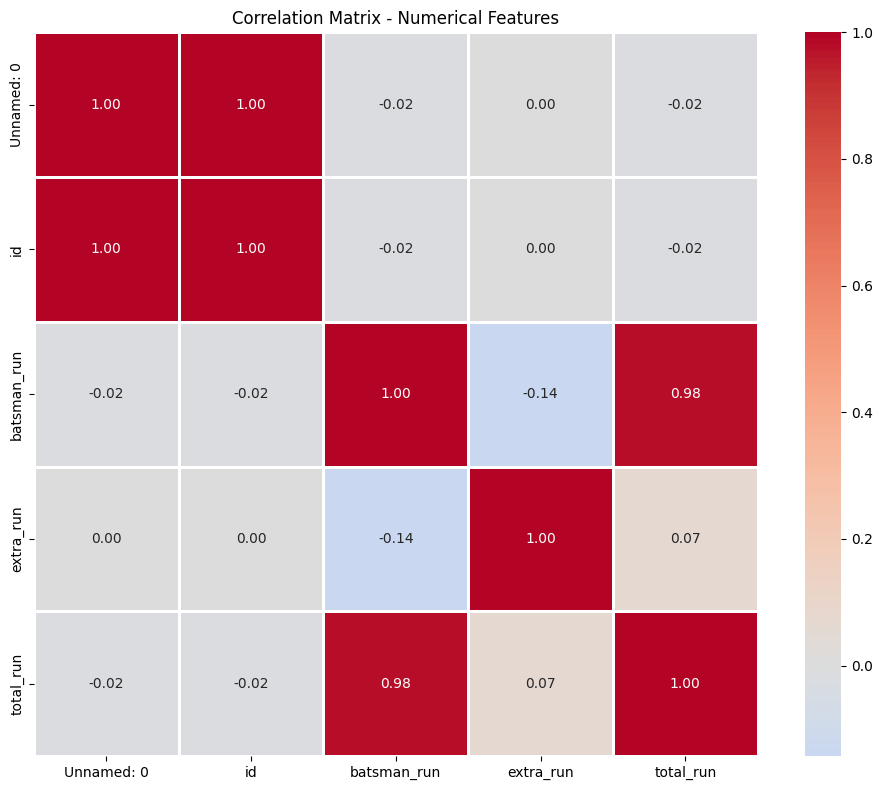


Correlation Matrix:
             Unnamed: 0        id  batsman_run  extra_run  total_run
Unnamed: 0     1.000000  0.999991    -0.019803   0.004918  -0.018936
id             0.999991  1.000000    -0.019941   0.004859  -0.019088
batsman_run   -0.019803 -0.019941     1.000000  -0.143050   0.978280
extra_run      0.004918  0.004859    -0.143050   1.000000   0.065212
total_run     -0.018936 -0.019088     0.978280   0.065212   1.000000


In [4]:
print("="*50)
print("CORRELATION ANALYSIS")
print("="*50)

numeric_cols = ball_by_ball.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(correlation_matrix)

TOP PERFORMERS ANALYSIS

Top 15 Batters by Total Runs:
batter_name
V Kohli           8670
RG Sharma         7048
S Dhawan          6769
DA Warner         6548
SK Raina          5536
MS Dhoni          5439
KL Rahul          5225
AB de Villiers    5124
AM Rahane         5032
CH Gayle          4987
RV Uthappa        4954
KD Karthik        4816
F du Plessis      4770
SV Samson         4704
AT Rayudu         4348
Name: batsman_run, dtype: int64

Top 15 Bowlers by Balls Bowled:
bowler_name
R Ashwin           4868
SP Narine          4421
B Kumar            4378
RA Jadeja          4109
YS Chahal          3905
PP Chawla          3895
Harbhajan Singh    3496
JJ Bumrah          3474
A Mishra           3444
AR Patel           3359
DJ Bravo           3296
Rashid Khan        3237
UT Yadav           3190
Sandeep Sharma     3168
SL Malinga         2974
Name: count, dtype: int64


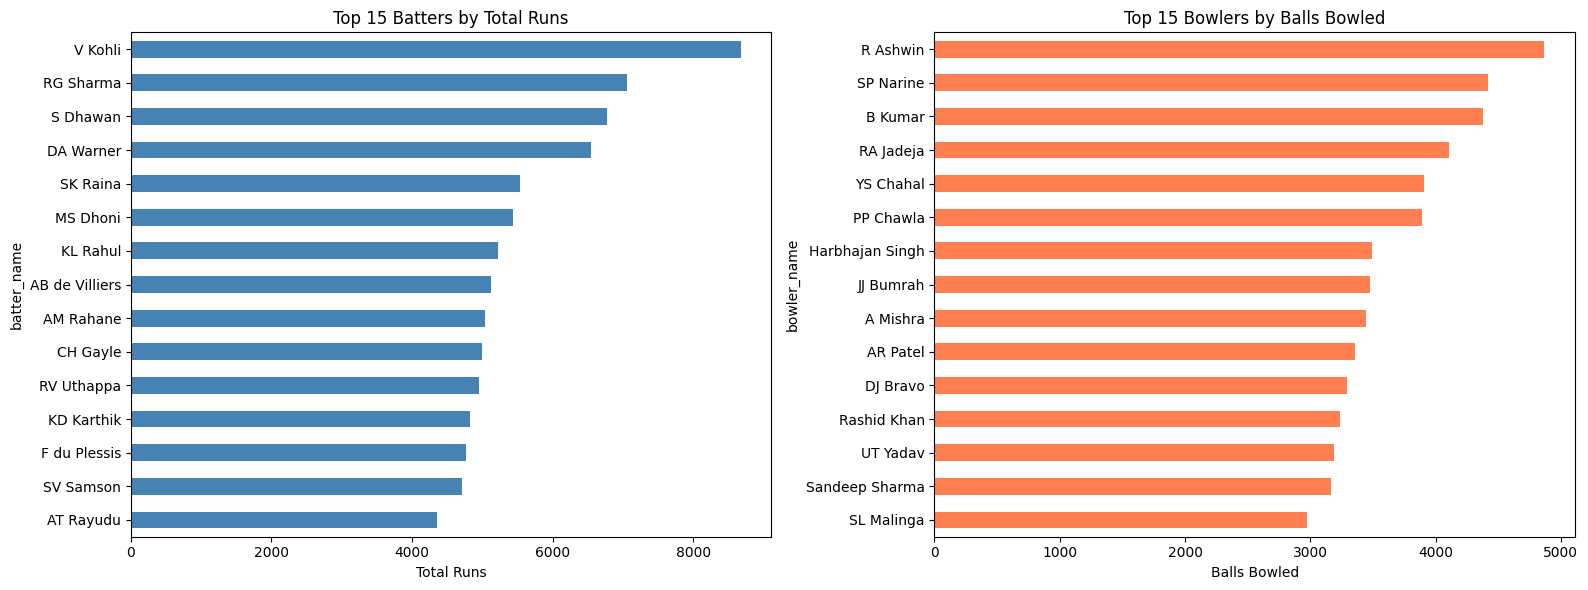

In [5]:
print("="*50)
print("TOP PERFORMERS ANALYSIS")
print("="*50)

print("\nTop 15 Batters by Total Runs:")
top_batters = ball_by_ball.groupby('batter_name')['batsman_run'].sum().sort_values(ascending=False).head(15)
print(top_batters)

print("\nTop 15 Bowlers by Balls Bowled:")
top_bowlers = ball_by_ball['bowler_name'].value_counts().head(15)
print(top_bowlers)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_batters.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Batters by Total Runs')
axes[0].set_xlabel('Total Runs')
axes[0].invert_yaxis()

top_bowlers.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Bowlers by Balls Bowled')
axes[1].set_xlabel('Balls Bowled')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()



TEAM ANALYSIS

Batting Team Distribution:
batting_team
Mumbai Indians                 33323
Kolkata Knight Riders          30895
Chennai Super Kings            30395
Royal Challengers Bangalore    28077
Rajasthan Royals               27922
Sunrisers Hyderabad            23442
Kings XI Punjab                22646
Delhi Daredevils               18723
Delhi Capitals                 12492
Deccan Chargers                 9034
Punjab Kings                    8802
Gujarat Titans                  7331
Lucknow Super Giants            7026
Pune Warriors                   5443
Gujarat Lions                   3566
Royal Challengers Bengaluru     3531
Rising Pune Supergiant          1900
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

Bowling Team Distribution:
bowling_team
Mumbai Indians                 33427
Kolkata Knight Riders          31169
Chennai Super Kings            30093
Royal Challengers Bangalore    28358
Rajasthan Royals           

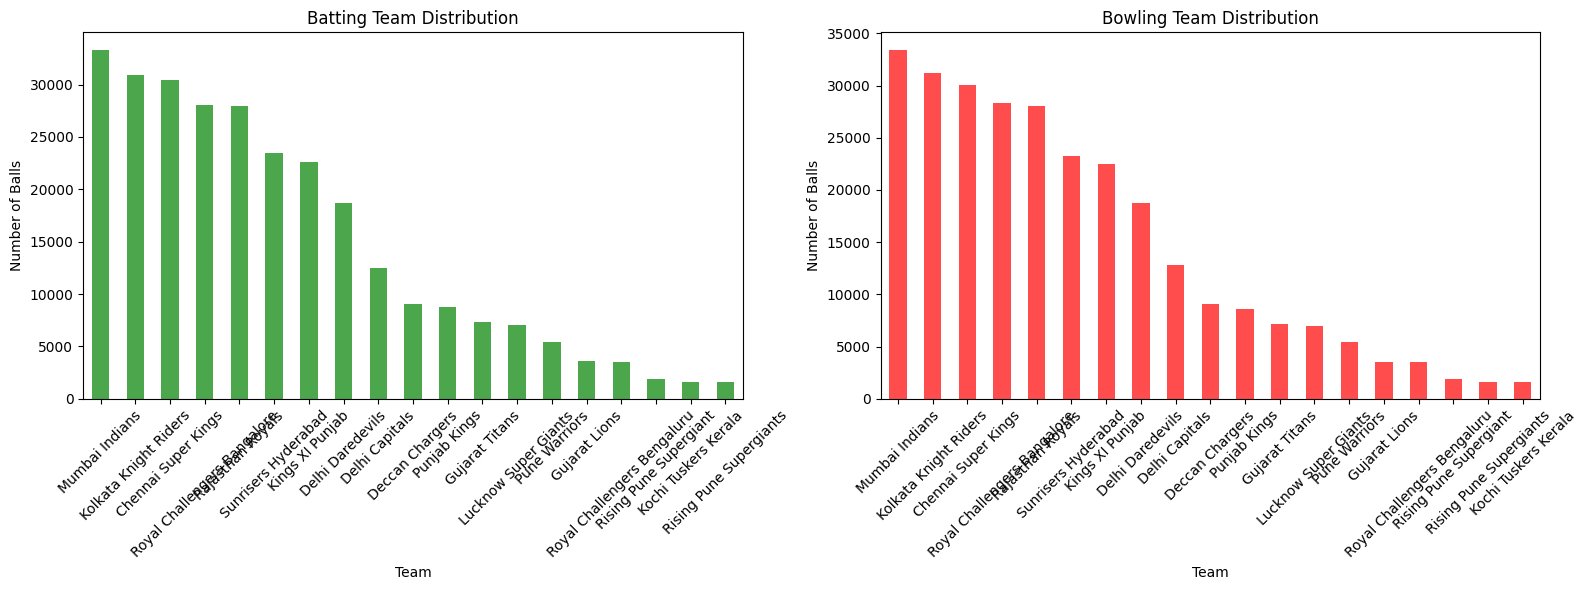

In [6]:
print("="*50)
print("TEAM ANALYSIS")
print("="*50)

print("\nBatting Team Distribution:")
batting_team_counts = ball_by_ball['batting_team'].value_counts()
print(batting_team_counts)

print("\nBowling Team Distribution:")
bowling_team_counts = ball_by_ball['bowling_team'].value_counts()
print(bowling_team_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

batting_team_counts.plot(kind='bar', ax=axes[0], color='green', alpha=0.7)
axes[0].set_title('Batting Team Distribution')
axes[0].set_xlabel('Team')
axes[0].set_ylabel('Number of Balls')
axes[0].tick_params(axis='x', rotation=45)

bowling_team_counts.plot(kind='bar', ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Bowling Team Distribution')
axes[1].set_xlabel('Team')
axes[1].set_ylabel('Number of Balls')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



RUN SCORING PATTERNS

Run Distribution:
batsman_run
0    110047
1    103006
2     17393
3       808
4     32057
5        67
6     14332
Name: count, dtype: int64


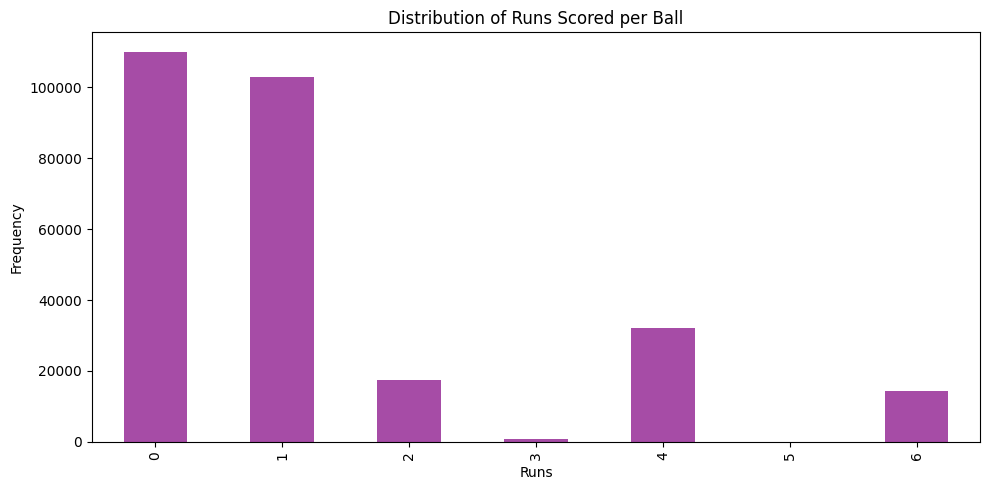

In [7]:
print("="*50)
print("RUN SCORING PATTERNS")
print("="*50)

print("\nRun Distribution:")
run_dist = ball_by_ball['batsman_run'].value_counts().sort_index()
print(run_dist)

plt.figure(figsize=(10, 5))
run_dist.plot(kind='bar', color='purple', alpha=0.7)
plt.title('Distribution of Runs Scored per Ball')
plt.xlabel('Runs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()




Extra Run Distribution:
extra_run
0    262604
1     13524
2       622
3        83
4       528
5       348
7         1
Name: count, dtype: int64


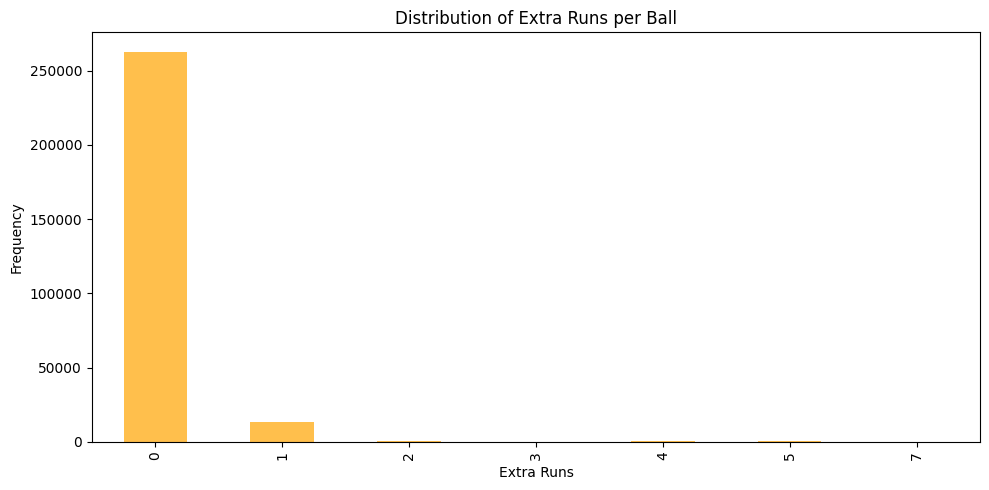

In [8]:
print("\nExtra Run Distribution:")
extra_dist = ball_by_ball['extra_run'].value_counts().sort_index()
print(extra_dist)

plt.figure(figsize=(10, 5))
extra_dist.plot(kind='bar', color='orange', alpha=0.7)
plt.title('Distribution of Extra Runs per Ball')
plt.xlabel('Extra Runs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



In [10]:
print("="*50)
print("BATTING PERFORMANCE METRICS")
print("="*50)

batter_stats = ball_by_ball.groupby('batter_name').agg({
    'batsman_run': ['sum', 'mean', 'count'],
    'id': 'nunique'
}).round(2)
batter_stats.columns = ['Total_Runs', 'Avg_Runs_Per_Ball', 'Balls_Faced', 'Matches_Played']
batter_stats = batter_stats.sort_values('Total_Runs', ascending=False).head(15)

print("\nTop 15 Batters - Detailed Stats:")
print(batter_stats)

print("="*50)
print("BOWLING PERFORMANCE METRICS")
print("="*50)

bowler_stats = ball_by_ball.groupby('bowler_name').agg({
    'batsman_run': ['sum', 'mean', 'count'],
    'id': 'nunique'
}).round(2)
bowler_stats.columns = ['Runs_Conceded', 'Avg_Runs_Per_Ball', 'Balls_Bowled', 'Matches_Played']
bowler_stats = bowler_stats[bowler_stats['Balls_Bowled'] >= 300].sort_values('Avg_Runs_Per_Ball').head(15)

print("\nTop 15 Economical Bowlers (min 300 balls):")
print(bowler_stats)

BATTING PERFORMANCE METRICS

Top 15 Batters - Detailed Stats:
                Total_Runs  Avg_Runs_Per_Ball  Balls_Faced  Matches_Played
batter_name                                                               
V Kohli               8670               1.29         6698             258
RG Sharma             7048               1.29         5475             266
S Dhawan              6769               1.23         5483             221
DA Warner             6548               1.35         4839             183
SK Raina              5536               1.33         4177             200
MS Dhoni              5439               1.33         4101             241
KL Rahul              5225               1.33         3933             134
AB de Villiers        5124               1.49         3440             169
AM Rahane             5032               1.22         4133             183
CH Gayle              4987               1.42         3512             140
RV Uthappa            4954            